In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
data=pd.read_csv('/content/dataset.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
data.shape

(2200, 8)

In [8]:
data.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [11]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [12]:
corr=data.drop('label', axis=1).corr()

In [13]:
corr

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


<Axes: >

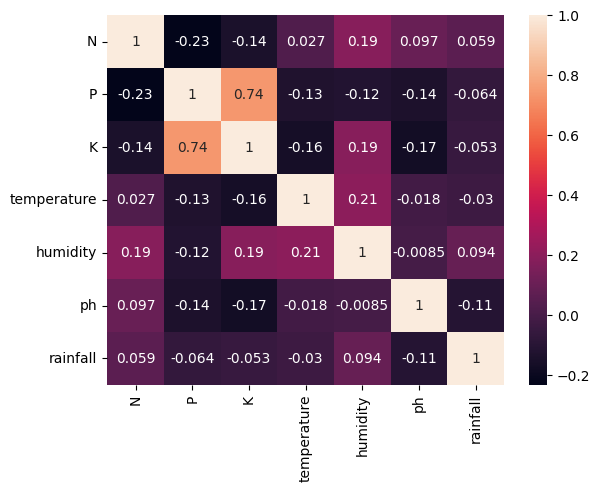

In [14]:
sns.heatmap(corr, annot=True)

In [15]:
data['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [16]:

data_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}

In [17]:
data = pd.read_csv('/content/dataset.csv')
data['label_num']=data['label'].map(data_dict)

In [18]:
data.drop('label',axis=1,inplace=True)

In [19]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [20]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# create instances of all models
models = {
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreeClassifier(),
}


In [25]:
from sklearn.metrics import accuracy_score
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{name}:\nAccuracy: {acc:.4f}')

Linear Discriminant Analysis:
Accuracy: 0.9515


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
Accuracy: 0.9485
Naive Bayes:
Accuracy: 0.9939
Support Vector Machine:
Accuracy: 0.9636
K-Nearest Neighbors:
Accuracy: 0.9773
Decision Tree:
Accuracy: 0.9864
Random Forest:
Accuracy: 0.9924
Bagging:
Accuracy: 0.9909
AdaBoost:
Accuracy: 0.1667
Gradient Boosting:
Accuracy: 0.9833
Extra Trees:
Accuracy: 0.9015


In [26]:
rdf = RandomForestClassifier()
rdf.fit(X_train,y_train)
y_pred = rdf.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))

Accuracy: 0.9924242424242424


In [30]:
import pickle

In [31]:
pickle.dump(rdf, open('model.pkl', 'wb'))
print('Model Saved Successfully')

Model Saved Successfully


In [27]:
def predict_crop(N, P, K, temperature, humidity, pH, rainfall):

    input_values = np.array([[N, P, K, temperature, humidity, pH, rainfall]])

    prediction = rdf.predict(input_values)

    return prediction[0]

In [28]:
N = 21
P = 26
K = 27
tem = 27.003155
humidity = 47.675254
ph = 5.699587
rainfall = 95.851183

pred = predict_crop(N, P, K, tem, humidity, ph, rainfall)

if pred == 1:
    print("Rice is the best crop to be cultivated right there")
elif pred == 2:
    print("Maize is the best crop to be cultivated right there")
elif pred == 3:
    print("Jute is the best crop to be cultivated right there")
elif pred == 4:
    print("Cotton is the best crop to be cultivated right there")
elif pred == 5:
    print("Coconut is the best crop to be cultivated right there")
elif pred == 6:
    print("Papaya is the best crop to be cultivated right there")
elif pred == 7:
    print("Orange is the best crop to be cultivated right there")
elif pred == 8:
    print("Apple is the best crop to be cultivated right there")
elif pred == 9:
    print("Muskmelon is the best crop to be cultivated right there")
elif pred == 10:
    print("Watermelon is the best crop to be cultivated right there")
elif pred == 11:
    print("Grapes is the best crop to be cultivated right there")
elif pred == 12:
    print("Mango is the best crop to be cultivated right there")
elif pred == 13:
    print("Banana is the best crop to be cultivated right there")
elif pred == 14:
    print("Pomegranate is the best crop to be cultivated right there")
elif pred == 15:
    print("Lentil is the best crop to be cultivated right there")
elif pred == 16:
    print("Blackgram is the best crop to be cultivated right there")
elif pred == 17:
    print("Mungbean is the best crop to be cultivated right there")
elif pred == 18:
    print("Mothbeans is the best crop to be cultivated right there")
elif pred == 19:
    print("Pigeonpeas is the best crop to be cultivated right there")
elif pred == 20:
    print("Kidneybeans is the best crop to be cultivated right there")
elif pred == 21:
    print("Chickpea is the best crop to be cultivated right there")
elif pred == 22:
    print("Coffee is the best crop to be cultivated right there")
else:
    print("Sorry, we could not determine the best crop to be cultivated with the provided data.")

Mango is the best crop to be cultivated right there


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [45]:
!pip install flask pyngrok scikit-learn pandas numpy

In [47]:
from flask import Flask, request

import numpy as np
import pickle

app = Flask(__name__)

# Load Model
model = pickle.load(open('model.pkl', 'rb'))

# Reverse Dictionary
crop_dict = {
    1: 'Rice',
    2: 'Maize',
    3: 'Jute',
    4: 'Cotton',
    5: 'Coconut',
    6: 'Papaya',
    7: 'Orange',
    8: 'Apple',
    9: 'Muskmelon',
    10: 'Watermelon',
    11: 'Grapes',
    12: 'Mango',
    13: 'Banana',
    14: 'Pomegranate',
    15: 'Lentil',
    16: 'Blackgram',
    17: 'Mungbean',
    18: 'Mothbeans',
    19: 'PigeonPeas',
    20: 'KidneyBeans',
    21: 'ChickPea',
    22: 'Coffee'
}

@app.route('/')
def home():
    return '''
    <html>
    <head>
        <title>Crop Recommendation</title>

        <style>
            body{
                font-family: Arial;
                background: linear-gradient(to right,#56ab2f,#a8e063);
                text-align:center;
                padding-top:40px;
            }

            .box{
                background:white;
                width:400px;
                margin:auto;
                padding:30px;
                border-radius:15px;
            }

            input{
                width:90%;
                padding:10px;
                margin:8px;
            }

            button{
                padding:10px 20px;
                background:green;
                color:white;
                border:none;
                border-radius:5px;
                cursor:pointer;
            }
        </style>

    </head>

    <body>

    <div class="box">

    <h1>Crop Recommendation System</h1>

    <form action="/predict" method="post">

    <input type="number" step="any" name="N" placeholder="Nitrogen" required><br>

    <input type="number" step="any" name="P" placeholder="Phosphorus" required><br>

    <input type="number" step="any" name="K" placeholder="Potassium" required><br>

    <input type="number" step="any" name="temperature" placeholder="Temperature" required><br>

    <input type="number" step="any" name="humidity" placeholder="Humidity" required><br>

    <input type="number" step="any" name="ph" placeholder="pH" required><br>

    <input type="number" step="any" name="rainfall" placeholder="Rainfall" required><br>

    <button type="submit">Predict Crop</button>

    </form>

    </div>

    </body>
    </html>
    '''

@app.route('/predict', methods=['POST'])
def predict():

    N = float(request.form['N'])
    P = float(request.form['P'])
    K = float(request.form['K'])
    temperature = float(request.form['temperature'])
    humidity = float(request.form['humidity'])
    ph = float(request.form['ph'])
    rainfall = float(request.form['rainfall'])

    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])

    prediction = model.predict(features)[0]

    crop = crop_dict[prediction]

    return f'''
    <h1 style="color:green;text-align:center;margin-top:100px;">
    {crop} is the Best Crop to Cultivate
    </h1>
    '''

print("Flask App Created")

Flask App Created


In [50]:
!ngrok config add-authtoken 3E5lZZsdR06eTlbqGnFsHMTISdh_tPgsNngkcJmSREWiFivd

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

# Open Tunnel
public_url = ngrok.connect(5000)

print(public_url)

# Run Flask
app.run(port=5000)

NgrokTunnel: "https://trifocals-iciness-operative.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [22/May/2026 19:21:45] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/May/2026 19:21:46] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [22/May/2026 19:22:10] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/May/2026 19:24:04] "GET / HTTP/1.1" 200 -
